Zadanie 9 -- Porownanie technik regularyzacji
Porownaj 5 technik zapobiegania overfitting na make_moons.

Wymagania:
- Techniki: (1) brak reg., (2) L2 alpha=0.01, (3) mala siec, (4) early stopping, (5) L2 + ES + mala siec
- n_samples=200, noise=0.3
- Narysuj granice decyzyjne (subplots 1x5)
- Tabela: train/test accuracy i gap

Oczekiwany wynik:
- 5 wykresow i tabela porownawcza

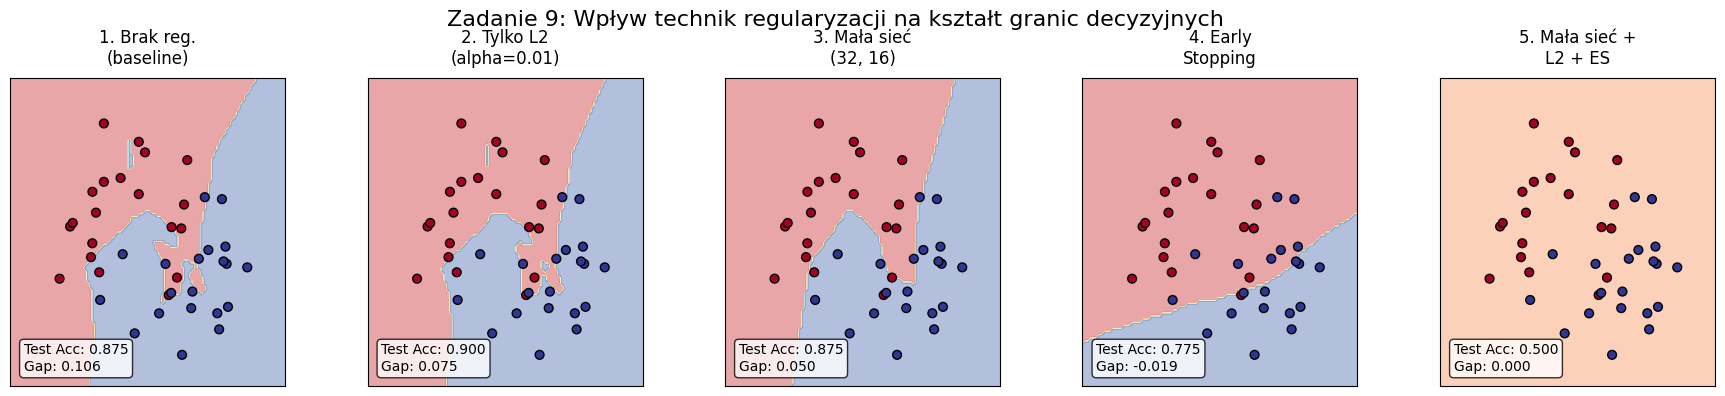


=== TABELA PORÓWNAWCZA: OVERFITTING GAP ===
Technika                  | Train Acc  | Test Acc   | Gap (Overfitting)
-----------------------------------------------------------------
1. Brak reg. (baseline)   | 0.9812     | 0.8750     | 0.1062
2. Tylko L2 (alpha=0.01)  | 0.9750     | 0.9000     | 0.0750
3. Mała sieć (32, 16)     | 0.9250     | 0.8750     | 0.0500
4. Early Stopping         | 0.7562     | 0.7750     | -0.0188
5. Mała sieć + L2 + ES    | 0.5000     | 0.5000     | 0.0000
-----------------------------------------------------------------
* Im mniejszy Gap, tym bardziej stabilny i mniej przeuczony jest model.


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import DecisionBoundaryDisplay

warnings.filterwarnings("ignore")

# 1. Przygotowanie danych (Zgodnie z wymogami: n_samples=200, co sprzyja overfittingowi)
X, y = make_moons(n_samples=200, noise=0.3, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# 2. Definicja 5 konfiguracji technik regularyzacji
configs = {
    '1. Brak reg.\n(baseline)': MLPClassifier(
        hidden_layer_sizes=(128, 64), alpha=0.0, max_iter=2000, random_state=42
    ),
    '2. Tylko L2\n(alpha=0.01)': MLPClassifier(
        hidden_layer_sizes=(128, 64), alpha=0.01, max_iter=2000, random_state=42
    ),
    '3. Mała sieć\n(32, 16)': MLPClassifier(
        hidden_layer_sizes=(32, 16), alpha=0.0, max_iter=2000, random_state=42
    ),
    '4. Early\nStopping': MLPClassifier(
        hidden_layer_sizes=(128, 64), alpha=0.0, early_stopping=True, 
        n_iter_no_change=10, max_iter=2000, random_state=42
    ),
    '5. Mała sieć +\nL2 + ES': MLPClassifier(
        hidden_layer_sizes=(32, 16), alpha=0.01, early_stopping=True, 
        n_iter_no_change=10, max_iter=2000, random_state=42
    )
}

results = []

# 3. Przygotowanie wykresów 1x5
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
plt.subplots_adjust(wspace=0.3)

for ax, (name, mlp) in zip(axes, configs.items()):
    # Trening modelu
    mlp.fit(X_train_sc, y_train)
    
    # Obliczenie metryk
    train_acc = mlp.score(X_train_sc, y_train)
    test_acc = mlp.score(X_test_sc, y_test)
    gap = train_acc - test_acc # Różnica pokazująca overfitting
    
    # Zapis do tabeli
    # Zamieniamy znaki nowej linii w nazwie na spacje dla ładnego druku w konsoli
    clean_name = name.replace('\n', ' ') 
    results.append([clean_name, train_acc, test_acc, gap])
    
    # Rysowanie granicy decyzyjnej
    DecisionBoundaryDisplay.from_estimator(
        mlp, X_train_sc, alpha=0.4, cmap="RdYlBu", eps=0.5, ax=ax, response_method="predict"
    )
    # Nanoszenie punktów TESTOWYCH (żeby zobaczyć, gdzie model się myli)
    ax.scatter(X_test_sc[:, 0], X_test_sc[:, 1], c=y_test, cmap="RdYlBu", edgecolors="k", s=40)
    
    ax.set_title(name, fontsize=12, pad=10)
    ax.set_xticks(())
    ax.set_yticks(())
    
    # Adnotacja z Acc i Gap na wykresie
    ax.annotate(f"Test Acc: {test_acc:.3f}\nGap: {gap:.3f}", 
                xy=(0.05, 0.05), xycoords='axes fraction', 
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8), fontsize=10)

plt.suptitle("Zadanie 9: Wpływ technik regularyzacji na kształt granic decyzyjnych", fontsize=16, y=1.05)
plt.show()

# 4. Wyświetlenie tabeli w konsoli
print("\n=== TABELA PORÓWNAWCZA: OVERFITTING GAP ===")
print(f"{'Technika':<25} | {'Train Acc':<10} | {'Test Acc':<10} | {'Gap (Overfitting)':<15}")
print("-" * 65)
for res in results:
    print(f"{res[0]:<25} | {res[1]:.4f}     | {res[2]:.4f}     | {res[3]:.4f}")
print("-" * 65)
print("* Im mniejszy Gap, tym bardziej stabilny i mniej przeuczony jest model.")

Zadanie 10 -- Propagacja sygnalu przez warstwy
Zbadaj jak BN stabilizuje propagacje sygnalu.

Wymagania:
- Siec: 10 warstw, 64 neurony, ReLU
- Propaguj 256 losowych probek przez siec
- Wariant 1: bez BN, Wariant 2: z BN
- Zapisz mean i std aktywacji per warstwa
- Narysuj 2 wykresy: std vs warstwa (z/bez BN)

Oczekiwany wynik:
- 2 wykresy porownawcze stabilnosci

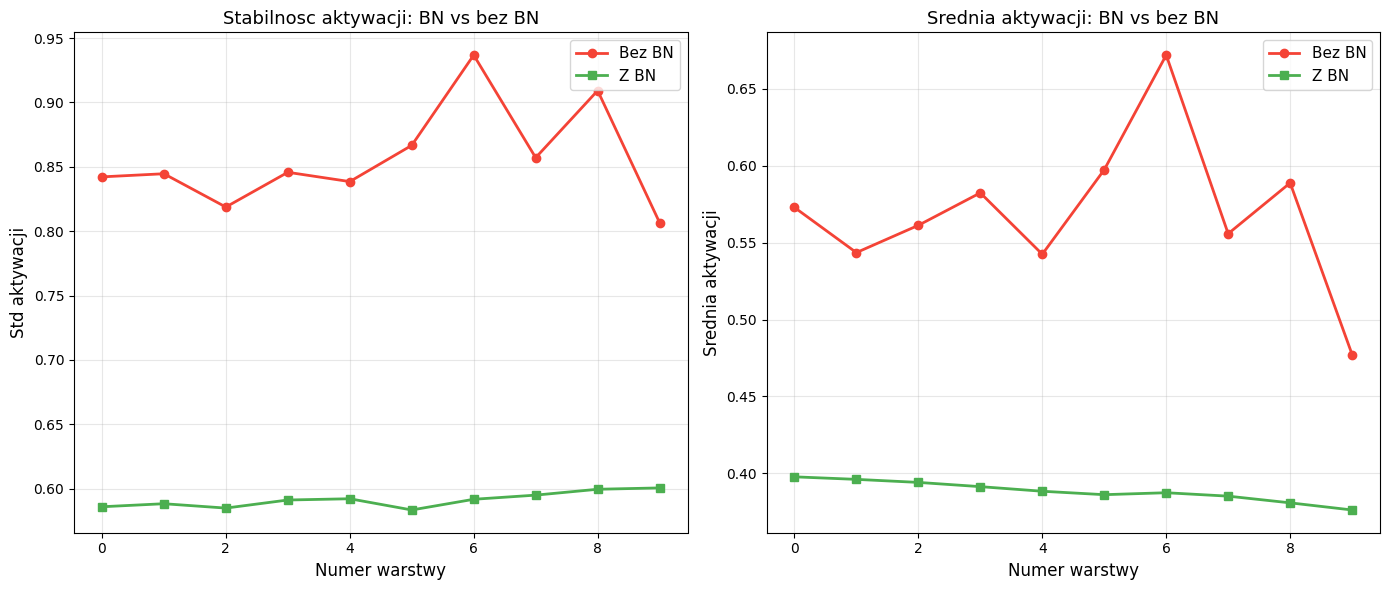

Bez BN: wraz z każdą kolejną warstwą średnia i odchylenie standardowe staj się coraz bardziej niestabilne
Z BN: aktywacje stabilne -- std blisko 1.0 w kazdej warstwie


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

# 1. Dodajemy prostą klasę BatchNorm, aby kod wiedział, co z nią zrobić
class BatchNorm:
    def __init__(self, n_neurons):
        self.gamma = np.ones(n_neurons)
        self.beta = np.zeros(n_neurons)
        self.eps = 1e-5

    def forward(self, x, training=True):
        mean = np.mean(x, axis=0)
        var = np.var(x, axis=0)
        # Normalizacja: odejmujemy średnią i dzielimy przez odchylenie
        x_norm = (x - mean) / np.sqrt(var + self.eps)
        return self.gamma * x_norm + self.beta

n_layers = 10
n_neurons = 64
n_samples = 256

# 2. Poprawka: Dodanie argumentu `use_batchnorm` do definicji funkcji
def propagate_layers(n_layers, use_batchnorm=False):
    """Symulacja forward pass przez wiele warstw."""
    x = np.random.randn(n_samples, n_neurons)
    means = []
    stds = []

    for layer in range(n_layers):
        W = np.random.randn(n_neurons, n_neurons) * np.sqrt(2.0 / n_neurons)
        x = x @ W

        if use_batchnorm:
            # Batch Normalization
            bn = BatchNorm(n_neurons)
            x = bn.forward(x, training=True)

        x = np.maximum(0, x) # ReLU

        means.append(x.mean())
        # 3. Poprawka literówki: zmieniono 'std' na 'stds'
        stds.append(x.std()) 

    return means, stds

np.random.seed(42)
means_no_bn, stds_no_bn = propagate_layers(n_layers, use_batchnorm=False)
means_bn, stds_bn = propagate_layers(n_layers, use_batchnorm=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.plot(range(n_layers), stds_no_bn, 'o-', color='#F44336', linewidth=2, label='Bez BN')
ax1.plot(range(n_layers), stds_bn, 's-', color='#4CAF50', linewidth=2, label='Z BN')
ax1.set_xlabel('Numer warstwy', fontsize=12)
ax1.set_ylabel('Std aktywacji', fontsize=12)
ax1.set_title('Stabilnosc aktywacji: BN vs bez BN', fontsize=13)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

ax2.plot(range(n_layers), means_no_bn, 'o-', color='#F44336', linewidth=2, label='Bez BN')
ax2.plot(range(n_layers), means_bn, 's-', color='#4CAF50', linewidth=2, label='Z BN')
ax2.set_xlabel('Numer warstwy', fontsize=12)
ax2.set_ylabel('Srednia aktywacji', fontsize=12)
ax2.set_title('Srednia aktywacji: BN vs bez BN', fontsize=13)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Bez BN: wraz z każdą kolejną warstwą średnia i odchylenie standardowe staj się coraz bardziej niestabilne")
print("Z BN: aktywacje stabilne -- std blisko 1.0 w kazdej warstwie")